# Hybrid Equivariant CNN + Quantum Neural Network for Gravitational Lensing Classification

This notebook combines a rotation-equivariant CNN (`e2cnn`) with a quantum neural network layer (`TorchQuantum`) for 3-class gravitational lensing classification.

In [1]:
import time
import os
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F

import torchquantum as tq
import numpy as np

from e2cnn import gspaces
from e2cnn import nn as e2nn

import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import seaborn as sns
from PIL import Image

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

os.environ["OMP_NUM_THREADS"] = "1"

print(f"TorchQuantum version: {tq.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

TorchQuantum version: 0.1.8
PyTorch version: 2.5.1+cu121
CUDA available: True


In [2]:
# =============================================================================
# Configuration
# =============================================================================

# Quantum circuit parameters
n_qubits = 8          # 8 qubits for better feature encoding
q_depth = 6           # 6 layers - balanced depth

# Training parameters
step = 0.0001         # Learning rate (lower for equivariant networks)
batch_size = 64
weight_decay = 1e-5
num_epochs = 42      # More epochs for from-scratch training
patience = 10         # Early stopping patience

# Model parameters
img_size = 128        # C8SteerableCNN uses 128x128 images
in_channels = 1       # Grayscale
num_classes = 3       # no_sub, sphere, vort

# Classical pre-processing dimensions
HIDDEN_DIM = 128
DROPOUT_RATE = 0.3

# Warmup epochs
WARMUP_EPOCHS = 5

# Data paths - UPDATE THESE TO YOUR DATA LOCATION
train_dir = "/home/jovyan/work/dataset/dataset/train"
val_dir = "/home/jovyan/work/dataset/dataset/val"

# Alternative: Use GEO's data structure
# train_dir = "data/Model_I"
# val_dir = "data/Model_I_test"

start_time = time.time()

print(f"Quantum circuit: {n_qubits} qubits, {q_depth} layers")
print(f"Image size: {img_size}x{img_size}")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Quantum circuit: 8 qubits, 6 layers
Image size: 128x128
Using device: cuda:0


In [3]:
# =============================================================================
# Data Loading
# =============================================================================

class NPYImageFolder(Dataset):
    """Dataset loader for .npy image files organized in class folders."""
    
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.classes = sorted([d for d in os.listdir(root_dir)
                               if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            for filename in os.listdir(class_dir):
                if filename.endswith('.npy'):
                    filepath = os.path.join(class_dir, filename)
                    self.samples.append((filepath, self.class_to_idx[class_name]))

        print(f"Found {len(self.samples)} samples in {root_dir}")
        print(f"Classes: {self.classes}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        arr = np.load(filepath, allow_pickle=True)
        
        # Handle different array formats
        if isinstance(arr, np.ndarray) and arr.ndim == 0:
            arr = arr.item()
        if isinstance(arr, (list, tuple)):
            arr = arr[0]

        if arr.ndim == 2:
            arr = arr[np.newaxis, :, :]
        elif arr.ndim == 3 and arr.shape[0] not in [1, 3]:
            arr = arr.transpose(2, 0, 1)

        # Normalize to [0, 1]
        if arr.max() > 1.0:
            arr = arr / arr.max()

        tensor = torch.tensor(arr, dtype=torch.float32)

        if self.transform:
            tensor = self.transform(tensor)

        return tensor, label


class NPYTransform:
    """Transform for NPY images with optional augmentation."""
    
    def __init__(self, img_size, augment=False):
        self.img_size = img_size
        self.augment = augment

    def __call__(self, x):
        # Resize if needed
        if x.shape[-1] != self.img_size or x.shape[-2] != self.img_size:
            x = F.interpolate(x.unsqueeze(0), size=(self.img_size, self.img_size),
                              mode='bilinear', align_corners=False).squeeze(0)

        if self.augment:
            # Random rotation (important for lensing data)
            if torch.rand(1) > 0.5:
                k = torch.randint(0, 4, (1,)).item()
                if k > 0:
                    x = torch.rot90(x, k, dims=[-2, -1])

            # Horizontal flip
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-1])

            # Vertical flip
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-2])

            # Small Gaussian noise
            if torch.rand(1) > 0.7:
                noise_std = torch.rand(1).item() * 0.03
                noise = torch.randn_like(x) * noise_std
                x = torch.clamp(x + noise, 0, 1)

            # Slight brightness variation
            if torch.rand(1) > 0.7:
                bf = 0.8 + torch.rand(1).item() * 0.4  # 0.8 to 1.2
                x = torch.clamp(x * bf, 0, 1)

        return x


def get_dataloaders(train_dir, val_dir, img_size, batch_size, test_split=0.10):
    """Create train, validation, and test dataloaders."""
    
    train_transform = NPYTransform(img_size, augment=True)
    val_transform = NPYTransform(img_size, augment=False)

    train_dataset = NPYImageFolder(train_dir, train_transform)
    val_full_dataset = NPYImageFolder(val_dir, val_transform)

    total_val = len(val_full_dataset)
    test_size = int(total_val * test_split)
    val_size = total_val - test_size

    val_dataset, test_dataset = random_split(
        val_full_dataset, [val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                            num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=0, pin_memory=True)

    return train_loader, val_loader, test_loader, train_dataset.classes

In [4]:
# =============================================================================
# Quantum Circuit
# =============================================================================

class QuantumCircuit(tq.QuantumModule):
    """
    Enhanced Quantum Circuit for gravitational lensing classification.
    - 8 qubits for finer feature encoding
    - RY + RZ + RX rotations (all three axes)
    - Asymmetric entanglement pattern
    """
    
    def __init__(self, n_qubits, q_depth):
        super().__init__()
        self.n_qubits = n_qubits
        self.q_depth = q_depth

        # RY variational layers
        self.ry_layers = nn.ModuleList([
            tq.Op1QAllLayer(op=tq.RY, n_wires=n_qubits, has_params=True, trainable=True)
            for _ in range(q_depth)
        ])

        # RZ variational layers
        self.rz_layers = nn.ModuleList([
            tq.Op1QAllLayer(op=tq.RZ, n_wires=n_qubits, has_params=True, trainable=True)
            for _ in range(q_depth)
        ])

        # RX variational layers
        self.rx_layers = nn.ModuleList([
            tq.Op1QAllLayer(op=tq.RX, n_wires=n_qubits, has_params=True, trainable=True)
            for _ in range(q_depth)
        ])

        # Per-qubit Z measurement
        self.measure = tq.MeasureAll(tq.PauliZ)

    def forward(self, q_input_features):
        batch_size = q_input_features.shape[0]

        qdev = tq.QuantumDevice(
            n_wires=self.n_qubits,
            bsz=batch_size,
            device=q_input_features.device
        )

        # Hadamard layer for superposition
        for i in range(self.n_qubits):
            qdev.h(wires=i)

        # Data encoding via RY gates
        for i in range(self.n_qubits):
            qdev.ry(wires=i, params=q_input_features[:, i])

        # Variational layers
        for k in range(self.q_depth):
            # Forward CNOT chain
            for i in range(self.n_qubits - 1):
                qdev.cnot(wires=[i, i + 1])

            # RY rotation
            self.ry_layers[k](qdev)

            # Reverse CNOT chain (asymmetric pattern)
            for i in range(self.n_qubits - 1, 0, -1):
                qdev.cnot(wires=[i, i - 1])

            # RZ rotation
            self.rz_layers[k](qdev)

            # Skip connections (long-range entanglement)
            for i in range(0, self.n_qubits - 2, 2):
                qdev.cnot(wires=[i, i + 2])

            # RX rotation
            self.rx_layers[k](qdev)

            # Circular connection
            qdev.cnot(wires=[self.n_qubits - 1, 0])

        return self.measure(qdev)

In [5]:
# =============================================================================
# Dressed Quantum Network (Classical Pre/Post Processing + Quantum)
# =============================================================================

class DressedQuantumNet(nn.Module):
    """
    Classical pre-processing -> Quantum Circuit -> Classical post-processing
    
    Takes features from ECNN and processes them through quantum circuit.
    """
    
    def __init__(self, input_features, n_qubits, q_depth, num_classes, dropout_rate=0.3):
        super().__init__()
        
        self.n_qubits = n_qubits

        # Classical pre-processing: gradual reduction to n_qubits
        self.pre_net = nn.Sequential(
            nn.Linear(input_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.8),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.6),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.4),
            
            nn.Linear(32, n_qubits),
        )

        self.quantum_circuit = QuantumCircuit(n_qubits, q_depth)

        # Post-processing: n_qubits -> num_classes
        self.post_net = nn.Sequential(
            nn.Linear(n_qubits, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, input_features):
        pre_out = self.pre_net(input_features)
        q_in = torch.tanh(pre_out) * np.pi / 2.0
        q_out = self.quantum_circuit(q_in)
        return self.post_net(q_out)

In [6]:
# =============================================================================
# C8 Steerable CNN (Equivariant Feature Extractor)
# =============================================================================

class C8SteerableCNN_Features(nn.Module):
    """
    C8 Steerable CNN for rotation-equivariant feature extraction.
    
    Uses e2cnn for C4 rotation equivariance (can be extended to C8).
    Returns flattened features instead of class predictions.
    """
    
    def __init__(self, n_rotations=4):
        super().__init__()
        
        # Define the rotation group
        self.r2_act = gspaces.Rot2dOnR2(N=n_rotations)
        
        # Input type: 1 channel (grayscale), trivial representation
        in_type = e2nn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        self.input_type = in_type
        
        # Block 1: 1 -> 24 regular representations
        out_type = e2nn.FieldType(self.r2_act, 24 * [self.r2_act.regular_repr])
        self.block1 = e2nn.SequentialModule(
            e2nn.MaskModule(in_type, 128, margin=1),
            e2nn.R2Conv(in_type, out_type, kernel_size=7, padding=1, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )
        
        # Block 2: 24 -> 48 regular representations
        in_type = self.block1.out_type
        out_type = e2nn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block2 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )
        self.pool1 = e2nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)
        
        # Block 3: 48 -> 48 regular representations
        in_type = self.block2.out_type
        out_type = e2nn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block3 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )
        
        # Block 4: 48 -> 96 regular representations
        in_type = self.block3.out_type
        out_type = e2nn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block4 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )
        self.pool2 = e2nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)
        
        # Block 5: 96 -> 96 regular representations
        in_type = self.block4.out_type
        out_type = e2nn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block5 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )
        
        # Block 6: 96 -> 64 regular representations
        in_type = self.block5.out_type
        out_type = e2nn.FieldType(self.r2_act, 64 * [self.r2_act.regular_repr])
        self.block6 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=1, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )
        self.pool3 = e2nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=1, padding=0)
        
        # Group pooling: makes output invariant to rotations
        self.gpool = e2nn.GroupPooling(out_type)
        
        # Calculate output feature size
        self.feature_size = self.gpool.out_type.size
    
    def forward(self, x):
        # Wrap input tensor in GeometricTensor
        x = e2nn.GeometricTensor(x, self.input_type)
        
        # Forward through equivariant blocks
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool1(x)
        
        x = self.block3(x)
        x = self.block4(x)
        x = self.pool2(x)
        
        x = self.block5(x)
        x = self.block6(x)
        x = self.pool3(x)
        
        # Group pooling for rotation invariance
        x = self.gpool(x)
        
        # Extract tensor and flatten
        x = x.tensor
        x = x.reshape(x.shape[0], -1)
        
        return x
    
    def get_output_size(self, input_size=128):
        """Calculate the output feature size for a given input size."""
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_size, input_size)
            out = self.forward(dummy)
            return out.shape[1]

In [7]:
# =============================================================================
# Hybrid ECNN + Quantum Model
# =============================================================================

class HybridECNN_QNN(nn.Module):
    """
    Hybrid model combining:
    - C8SteerableCNN: Rotation-equivariant feature extraction
    - DressedQuantumNet: Quantum circuit with classical pre/post processing
    
    The equivariant CNN extracts rotation-invariant features,
    which are then processed by the quantum circuit for classification.
    """
    
    def __init__(self, n_rotations=4, n_qubits=8, q_depth=6, 
                 num_classes=3, dropout_rate=0.3, img_size=128):
        super().__init__()
        
        self.img_size = img_size
        
        # Equivariant feature extractor
        self.ecnn = C8SteerableCNN_Features(n_rotations=n_rotations)
        
        # Get the output feature size from ECNN
        ecnn_output_size = self.ecnn.get_output_size(img_size)
        print(f"ECNN output feature size: {ecnn_output_size}")
        
        # Quantum classifier
        self.quantum_fc = DressedQuantumNet(
            input_features=ecnn_output_size,
            n_qubits=n_qubits,
            q_depth=q_depth,
            num_classes=num_classes,
            dropout_rate=dropout_rate
        )
        
    def forward(self, x):
        # Extract equivariant features
        features = self.ecnn(x)
        # Classify with quantum circuit
        output = self.quantum_fc(features)
        return output
    
    def get_parameter_groups(self, base_lr, ecnn_lr_factor=1.0):
        """Get parameter groups with different learning rates."""
        param_groups = [
            {
                'params': self.ecnn.parameters(),
                'lr': base_lr * ecnn_lr_factor,
                'name': 'ecnn_backbone'
            },
            {
                'params': self.quantum_fc.parameters(),
                'lr': base_lr,
                'name': 'quantum_fc'
            }
        ]
        return param_groups

In [8]:
# =============================================================================
# Training Functions
# =============================================================================

def warmup_cosine_lambda(epoch, warmup_epochs, total_epochs):
    """Learning rate schedule with warmup and cosine annealing."""
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    return 0.5 * (1.0 + np.cos(np.pi * progress))


def train_model(model, criterion, optimizer, scheduler, dataloaders, 
                dataset_sizes, num_epochs, patience=20, device='cuda'):
    """Train the hybrid ECNN + QNN model."""
    
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_loss = float('inf')
    epochs_no_improve = 0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print("Training started:")
    print(f"  Early stopping patience: {patience} epochs")
    print(f"  Warmup epochs: {WARMUP_EPOCHS}")

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 35)

        for phase in ["train", "validation"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            pbar = tqdm(dataloaders[phase], desc=f"{phase}")
            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == "train":
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
                scheduler.step()
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    print(f"  New best model! (val_acc={best_acc:.4f})")
                else:
                    epochs_no_improve += 1

                if epoch_loss < best_loss:
                    best_loss = epoch_loss

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

    time_elapsed = time.time() - since
    print(f"\nTraining completed in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history


@torch.no_grad()
def evaluate_model(model, test_loader, device='cuda'):
    """Evaluate model on test set."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    try:
        roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except Exception:
        roc_auc = 0.0

    return accuracy, all_preds, all_labels, all_probs, roc_auc

In [9]:
# =============================================================================
# Visualization Functions
# =============================================================================

def plot_training_history(history, n_qubits, q_depth):
    """Plot training and validation curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss Curve', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[1].plot(history['val_acc'], label='Validation', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Accuracy Curve', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'ECNN + Quantum - {n_qubits} Qubits, {q_depth} Layers',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves_ecnn_qnn.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(test_labels, test_preds, class_names, test_acc):
    """Plot confusion matrix."""
    cm = confusion_matrix(test_labels, test_preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title('Confusion Matrix (Counts)')

    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_title('Confusion Matrix (Percentage %)')

    plt.suptitle(f'Test Set - Accuracy: {test_acc*100:.2f}%', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('confusion_matrix_ecnn_qnn.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return cm


def plot_roc_curves(test_labels, test_probs, class_names):
    """Plot ROC curves."""
    n_classes_eval = len(class_names)
    y_true_bin = label_binarize(test_labels, classes=list(range(n_classes_eval)))
    y_scores = np.array(test_probs)

    fpr, tpr, roc_auc_dict = {}, {}, {}
    for i in range(n_classes_eval):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc_dict[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
    roc_auc_dict["micro"] = auc(fpr["micro"], tpr["micro"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = ['#2ecc71', '#3498db', '#e74c3c']

    for i, (cls, color) in enumerate(zip(class_names, colors)):
        axes[0].plot(fpr[i], tpr[i], color=color, lw=2,
                     label=f'{cls} (AUC = {roc_auc_dict[i]:.4f})')

    axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.5)')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].set_title('ROC Curve (Per Class)', fontsize=14, fontweight='bold')
    axes[0].legend(loc='lower right', fontsize=10)
    axes[0].grid(alpha=0.3)

    axes[1].fill_between(fpr["micro"], tpr["micro"], alpha=0.3, color='#3498db')
    axes[1].plot(fpr["micro"], tpr["micro"], color='#3498db', lw=3,
                 label=f'Micro-average (AUC = {roc_auc_dict["micro"]:.4f})')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.5)')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate', fontsize=12)
    axes[1].set_ylabel('True Positive Rate', fontsize=12)
    axes[1].set_title('ROC Curve (Micro-Average)', fontsize=14, fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=11)
    axes[1].grid(alpha=0.3)

    plt.suptitle('ECNN + Quantum - ROC Curves', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('roc_curves_ecnn_qnn.png', dpi=150, bbox_inches='tight')
    plt.show()

    return roc_auc_dict


def plot_per_class_accuracy(cm, class_names, test_acc):
    """Plot per-class accuracy bar chart."""
    per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    bars = ax.bar(class_names, per_class_acc, color=colors, edgecolor='black', linewidth=1.5)

    for bar, acc in zip(bars, per_class_acc):
        height = bar.get_height()
        ax.annotate(f'{acc:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_xlabel('Class', fontsize=12)
    ax.set_title('Per-Class Test Accuracy', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.axhline(y=test_acc*100, color='red', linestyle='--',
               label=f'Overall Accuracy: {test_acc*100:.1f}%', linewidth=2)
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('per_class_accuracy_ecnn_qnn.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return per_class_acc

Loading data...
Found 30000 samples in /home/jovyan/work/dataset/dataset/train
Classes: ['no', 'sphere', 'vort']
Found 7500 samples in /home/jovyan/work/dataset/dataset/val
Classes: ['no', 'sphere', 'vort']
Dataset sizes: {'train': 30000, 'validation': 6750}
Classes: ['no', 'sphere', 'vort']
Test set size: 750
Batch shape: torch.Size([64, 1, 128, 128])


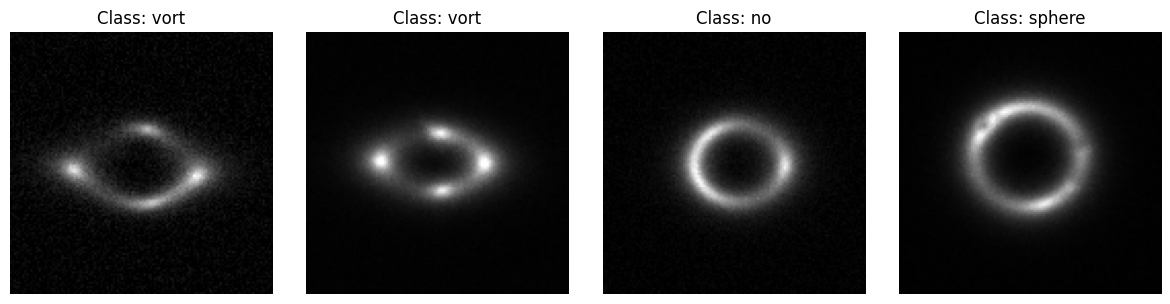


Creating Hybrid ECNN + QNN model...


/home/jovyan/tq-clean/lib/python3.10/site-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)
  full_mask[mask] = norms.to(torch.uint8)


ECNN output feature size: 40000

Parameter Summary:
  Total parameters: 11,333,947
  Trainable parameters: 11,317,563
  Trainable ratio: 99.9%

Class weights: {'no': 1.0, 'sphere': 2.5, 'vort': 2.0}

Optimizer Learning Rates:
  ecnn_backbone: lr=0.000100
  quantum_fc: lr=0.000100

Starting Training...
Training started:
  Early stopping patience: 10 epochs
  Warmup epochs: 5

Epoch 1/42
-----------------------------------


train: 100%|██████████| 469/469 [03:52<00:00,  2.02it/s, loss=1.1002]


train Loss: 1.0973 Acc: 0.3333


...

validation Loss: 0.1924 Acc: 0.9603

Epoch 42/42
-----------------------------------


train: 100%|██████████| 469/469 [02:07<00:00,  3.67it/s, loss=0.4831]


train Loss: 0.2562 Acc: 0.9364


validation: 100%|██████████| 106/106 [00:14<00:00,  7.32it/s, loss=0.1644]


validation Loss: 0.1929 Acc: 0.9613
  New best model! (val_acc=0.9613)

Training completed in 106m 39s
Best val Acc: 0.9613


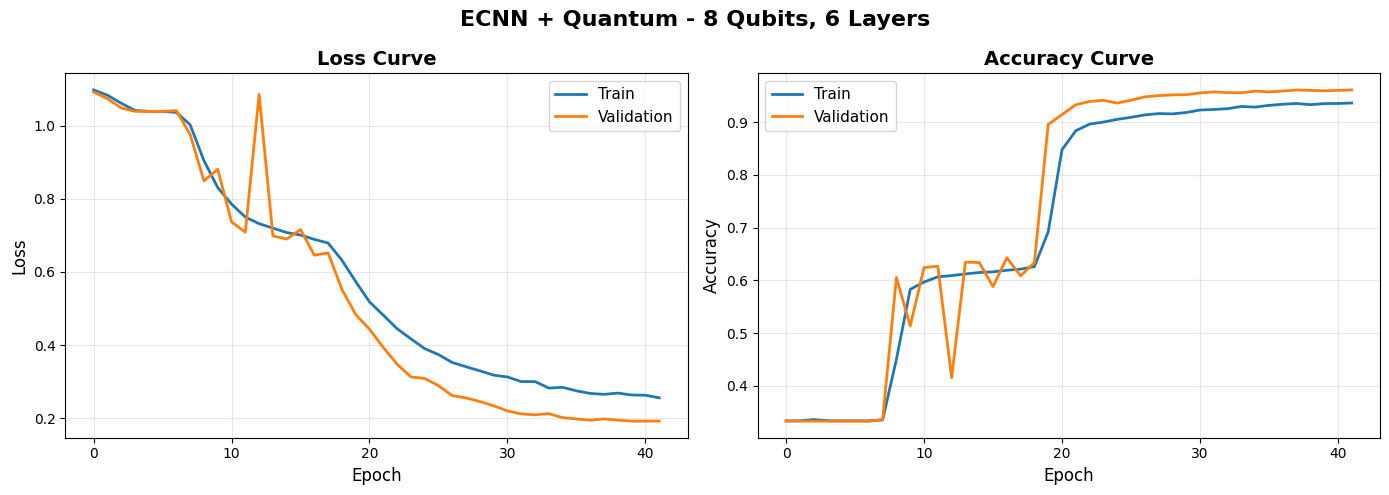


Best Validation Accuracy: 96.13%

Evaluating on Test Set...


Testing: 100%|██████████| 12/12 [00:03<00:00,  3.58it/s]


Test Accuracy: 94.93%
Test ROC-AUC:  0.9812


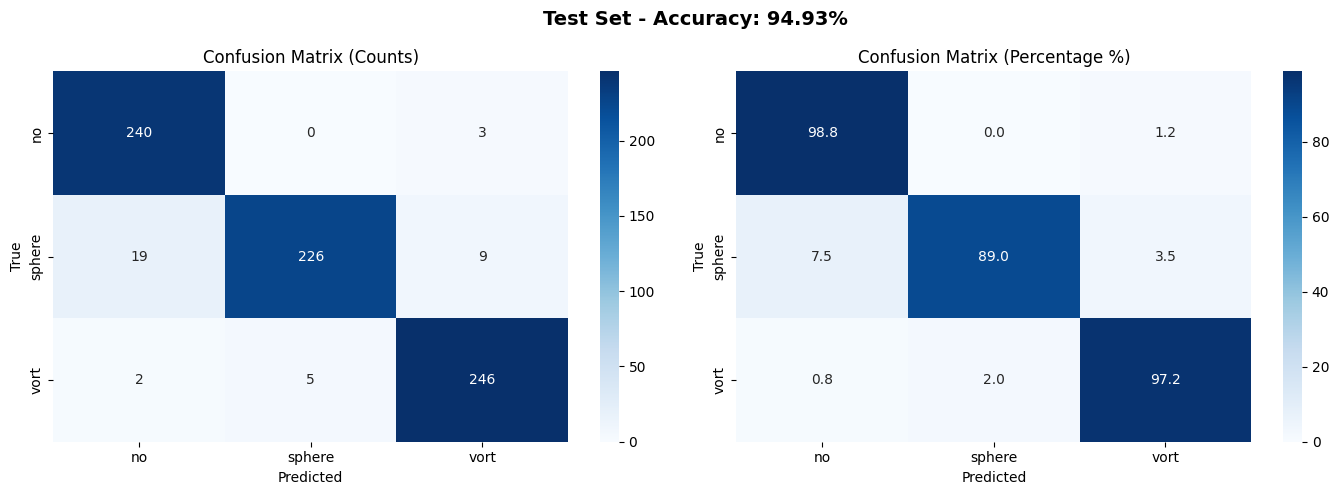


Classification Report:
              precision    recall  f1-score   support

          no     0.9195    0.9877    0.9524       243
      sphere     0.9784    0.8898    0.9320       254
        vort     0.9535    0.9723    0.9628       253

    accuracy                         0.9493       750
   macro avg     0.9505    0.9499    0.9491       750
weighted avg     0.9509    0.9493    0.9490       750



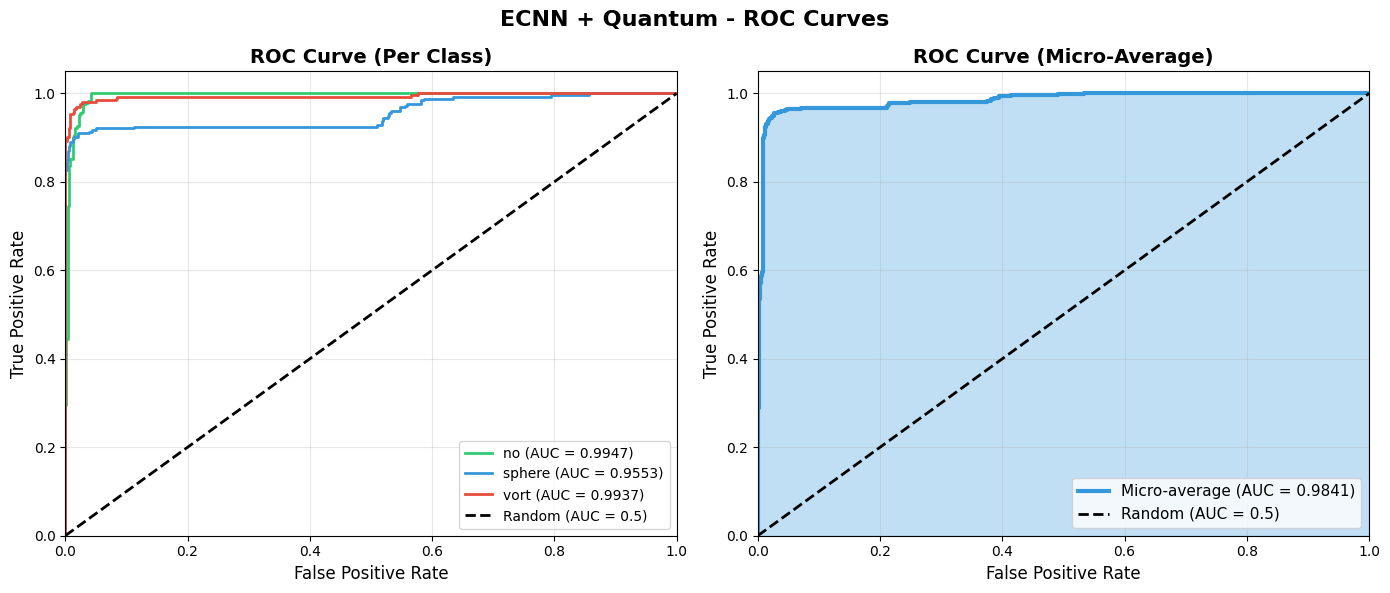


ROC-AUC Summary:
  no: AUC = 0.9947
  sphere: AUC = 0.9553
  vort: AUC = 0.9937
  Micro-average: AUC = 0.9841


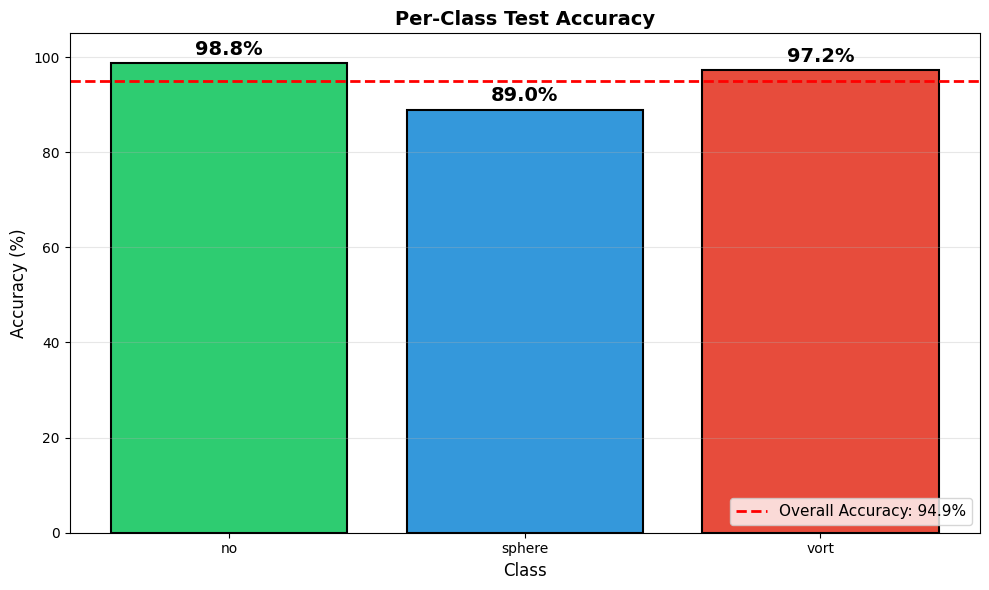


Model saved to: hybrid_ecnn_qnn_torchquantum.pth

     ECNN + QUANTUM NEURAL NETWORK - FINAL SUMMARY

Architecture:
  Classical Backbone: C8SteerableCNN (C4 rotation equivariant)
  Quantum Circuit: 8 qubits, 6 layers
  Rotations: RY + RZ + RX (all three axes)
  Entanglement: Forward + Reverse + Skip + Circular

Training Settings:
  Learning rate: 0.0001
  Batch size: 64
  Weight decay: 1e-05
  Warmup epochs: 5
  Max epochs: 42
  Early stopping patience: 10

Performance:
  Best Validation Accuracy: 96.13%
  Test Accuracy: 94.93%
  Test ROC-AUC: 0.9812

Per-Class Test Accuracy:
  no: 98.77%
  sphere: 88.98%
  vort: 97.23%

Total Training Time: 106.9 minutes
                     EVALUATION COMPLETE


In [10]:
# =============================================================================
# Main Training Script
# =============================================================================

# Load data
print("Loading data...")
train_loader, val_loader, test_loader, class_names = get_dataloaders(
    train_dir, val_dir, img_size, batch_size, test_split=0.10
)

dataset_sizes = {
    "train": len(train_loader.dataset),
    "validation": len(val_loader.dataset)
}
dataloaders = {"train": train_loader, "validation": val_loader}

print(f"Dataset sizes: {dataset_sizes}")
print(f"Classes: {class_names}")
print(f"Test set size: {len(test_loader.dataset)}")

# Visualize sample batch
inputs, classes_batch = next(iter(dataloaders["train"]))
print(f"Batch shape: {inputs.shape}")

fig, axes = plt.subplots(1, min(4, len(inputs)), figsize=(12, 3))
for i in range(min(4, len(inputs))):
    ax = axes[i] if len(inputs) > 1 else axes
    img = inputs[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Class: {class_names[classes_batch[i]]}')
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

# Create model
print("\nCreating Hybrid ECNN + QNN model...")
model = HybridECNN_QNN(
    n_rotations=4,      # C4 rotation equivariance
    n_qubits=n_qubits,
    q_depth=q_depth,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    img_size=img_size
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nParameter Summary:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Trainable ratio: {trainable_params/total_params*100:.1f}%")

# Loss function with class weights
class_weights = torch.tensor([1.0, 2.5, 2.0], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f"\nClass weights: {dict(zip(class_names, class_weights.tolist()))}")

# Optimizer with parameter groups
param_groups = model.get_parameter_groups(step, ecnn_lr_factor=1.0)
print(f"\nOptimizer Learning Rates:")
for pg in param_groups:
    print(f"  {pg['name']}: lr={pg['lr']:.6f}")

optimizer = optim.Adam(param_groups, weight_decay=weight_decay)

# Learning rate scheduler
scheduler = lr_scheduler.LambdaLR(
    optimizer, 
    lr_lambda=lambda epoch: warmup_cosine_lambda(epoch, WARMUP_EPOCHS, num_epochs)
)

# Train model
print("\n" + "="*60)
print("Starting Training...")
print("="*60)

model, history = train_model(
    model, criterion, optimizer, scheduler, dataloaders,
    dataset_sizes, num_epochs=num_epochs, patience=patience, device=device
)

# Plot training history
plot_training_history(history, n_qubits, q_depth)
print(f"\nBest Validation Accuracy: {max(history['val_acc'])*100:.2f}%")

# Evaluate on test set
print("\n" + "="*60)
print("Evaluating on Test Set...")
print("="*60)

test_acc, test_preds, test_labels, test_probs, test_roc_auc = evaluate_model(
    model, test_loader, device=device
)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test ROC-AUC:  {test_roc_auc:.4f}")

# Plot results
cm = plot_confusion_matrix(test_labels, test_preds, class_names, test_acc)

print("\nClassification Report:")
print("="*60)
print(classification_report(test_labels, test_preds,
                            target_names=class_names, digits=4))

roc_auc_dict = plot_roc_curves(test_labels, test_probs, class_names)

print("\nROC-AUC Summary:")
print("="*50)
for i, cls in enumerate(class_names):
    print(f"  {cls}: AUC = {roc_auc_dict[i]:.4f}")
print(f"  Micro-average: AUC = {roc_auc_dict['micro']:.4f}")

per_class_acc = plot_per_class_accuracy(cm, class_names, test_acc)

# Save model
model_save_path = "hybrid_ecnn_qnn_torchquantum.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'config': {
        'n_qubits': n_qubits,
        'q_depth': q_depth,
        'n_rotations': 4,
        'dropout_rate': DROPOUT_RATE,
        'num_classes': num_classes,
        'class_names': class_names,
        'img_size': img_size,
        'quantum_backend': 'torchquantum',
    },
    'test_accuracy': test_acc,
    'test_roc_auc': test_roc_auc,
}, model_save_path)
print(f"\nModel saved to: {model_save_path}")

# Final summary
print("\n" + "="*70)
print("     ECNN + QUANTUM NEURAL NETWORK - FINAL SUMMARY")
print("="*70)

print(f"\nArchitecture:")
print(f"  Classical Backbone: C8SteerableCNN (C4 rotation equivariant)")
print(f"  Quantum Circuit: {n_qubits} qubits, {q_depth} layers")
print(f"  Rotations: RY + RZ + RX (all three axes)")
print(f"  Entanglement: Forward + Reverse + Skip + Circular")

print(f"\nTraining Settings:")
print(f"  Learning rate: {step}")
print(f"  Batch size: {batch_size}")
print(f"  Weight decay: {weight_decay}")
print(f"  Warmup epochs: {WARMUP_EPOCHS}")
print(f"  Max epochs: {num_epochs}")
print(f"  Early stopping patience: {patience}")

print(f"\nPerformance:")
print(f"  Best Validation Accuracy: {max(history['val_acc'])*100:.2f}%")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Test ROC-AUC: {test_roc_auc:.4f}")

print(f"\nPer-Class Test Accuracy:")
for i, cls in enumerate(class_names):
    print(f"  {cls}: {per_class_acc[i]:.2f}%")

print(f"\nTotal Training Time: {(time.time() - start_time)/60:.1f} minutes")
print("="*70)
print("                     EVALUATION COMPLETE")
print("="*70)

In [11]:
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc, f1_score)


In [12]:
@torch.no_grad()
def evaluate_model(model, test_loader, device='cuda'):
    """Evaluate model on test set."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    try:
        roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except Exception:
        roc_auc = 0.0

    return accuracy, all_preds, all_labels, all_probs, roc_auc, f1_macro, f1_weighted


In [13]:
# Evaluate on test set
test_acc, test_preds, test_labels, test_probs, test_roc_auc, test_f1_macro, test_f1_weighted = evaluate_model(
    model, test_loader, device=device
)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test ROC-AUC:  {test_roc_auc:.4f}")
print(f"Test F1 (macro):    {test_f1_macro:.4f}")
print(f"Test F1 (weighted): {test_f1_weighted:.4f}")


Testing: 100%|██████████| 12/12 [00:01<00:00,  7.22it/s]

Test Accuracy: 94.93%
Test ROC-AUC:  0.9812
Test F1 (macro):    0.9491
Test F1 (weighted): 0.9490


In [14]:
print(f"\nPerformance:")
print(f"  Best Validation Accuracy: {max(history['val_acc'])*100:.2f}%")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Test ROC-AUC: {test_roc_auc:.4f}")
print(f"  Test F1 (macro): {test_f1_macro:.4f}")
print(f"  Test F1 (weighted): {test_f1_weighted:.4f}")



Performance:
  Best Validation Accuracy: 96.13%
  Test Accuracy: 94.93%
  Test ROC-AUC: 0.9812
  Test F1 (macro): 0.9491
  Test F1 (weighted): 0.9490
